In [1]:
import geopandas as gpd

In [ ]:
#gdf= gpd.read_parquet("./data/e005_n50_e010_n45.parquet")
#gdf

# too big for memory

In [2]:
gba = gpd.read_file("./data/GBA_buildings_clipped.geojson")

In [3]:
gba

,bbox,height,id,region,source,var,geometry
0,"{'xmin': 9.055230549089705, 'ymin': 49.6118227...",2.290915,Germany_120203320_179341,DEU,ms,0.596883,"POLYGON ((9.05523 49.61183, 9.05532 49.61182, ..."
1,"{'xmin': 9.055753351830804, 'ymin': 49.6120178...",3.868619,Germany_120203320_98296,DEU,ms,0.130063,"POLYGON ((9.05575 49.61207, 9.05576 49.61202, ..."
2,"{'xmin': 9.055747493444189, 'ymin': 49.6130979...",4.879138,Germany_120203320_28526,DEU,ms,0.928413,"POLYGON ((9.05575 49.6131, 9.05584 49.6131, 9...."
3,"{'xmin': 9.05571259144662, 'ymin': 49.61310856...",3.549916,Germany_120203320_270227,DEU,ms,0.765195,"POLYGON ((9.05571 49.61311, 9.05574 49.61311, ..."
4,"{'xmin': 9.056484837180697, 'ymin': 49.6148615...",3.692756,Germany_120203320_265375,DEU,ms,0.436723,"POLYGON ((9.05648 49.61493, 9.05653 49.61486, ..."
...,...,...,...,...,...,...,...
287057,"{'xmin': 9.18546008038129, 'ymin': 49.68453544...",3.445773,7335,DEU,ours2,0.519252,"POLYGON ((9.18546 49.68461, 9.1855 49.68454, 9..."
287058,"{'xmin': 9.18697164783623, 'ymin': 49.68351339...",2.952043,7553,DEU,ours2,1.118956,"POLYGON ((9.18697 49.68358, 9.18697 49.68353, ..."
287059,"{'xmin': 8.602178911831189, 'ymin': 48.1710110...",2.923485,Germany_120221102_80808,DEU,ms,0.682701,"POLYGON ((8.60222 48.17107, 8.60222 48.17101, ..."
287060,"{'xmin': 9.861813758732172, 'ymin': 45.6410420...",3.479154,Italy_120221330_64806,ITA,ms,0.493881,"POLYGON ((9.862 45.64106, 9.86183 45.64104, 9...."


<Axes: >

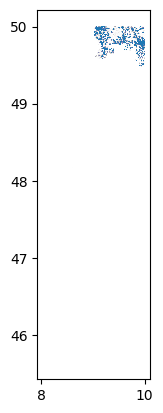

In [5]:
gba.plot()

# create würzburg boundary

In [4]:
wue_stadtbezirke = gpd.read_file("./data/stadtbezirke.geojson")
#https://opendata.wuerzburg.de/explore/dataset/stadtbezirke/export/ 

In [5]:
wue_boundaries = wue_stadtbezirke.dissolve()

In [6]:
wue_boundaries["name"] = "Würzburg" 
wue_boundaries["stadtbezir"] = "Würzburg"

In [19]:
wue_boundaries.to_file("./data/wue_boundaries.geojson", driver="GeoJSON")

# clip GBA data to wue area

In [7]:
gba_wue = gba.clip(wue_boundaries)

TypeError: cannot unpack non-iterable Axes object

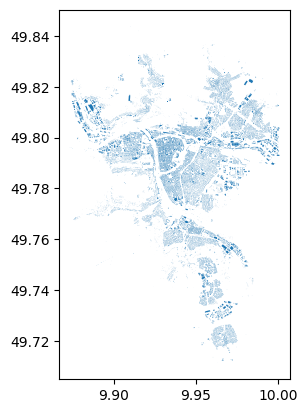

In [ ]:
gba_wue.plot()

In [8]:
import matplotlib.pyplot as plt

In [15]:
%matplotlib qt

In [ ]:
gba_wue.plot(alpha=0.3)
plt.axis('off')
#plt.gca().set_position([0, 0, 1, 1])
plt.savefig("gba_wue.svg")

(np.float64(9.866770204879133),
 np.float64(10.0075614521726),
 np.float64(49.70487247569463),
 np.float64(49.850356406281186))

In [23]:
gba_wue.to_file("./data/gba_wue.geojson", driver="GeoJSON")